# TrialCriteriaNER

**Structuring clinical-trial eligibility criteria with transformer-based NER**

This notebook is the exam-facing research report. Reusable training and evaluation
logic lives in `src/trial_criteria_ner/` and `scripts/`. Heavy training is not
repeated here; instead we reload locked metrics and demonstrate the core pipeline.

## Research question

Can a compact DistilBERT token classifier identify medical entities in clinical-trial
eligibility criteria more accurately than a classical CRF baseline on the same
held-out CHIA test set?

## 1. Problem statement

Eligibility criteria are usually free text, for example:

> Patients with diabetes and HbA1c above 7% receiving metformin.

Useful structured entities include `Condition`, `Measurement`, `Value`, and `Drug`.
Manual structuring does not scale across ClinicalTrials.gov. Named Entity Recognition
(NER) is a first step toward searchable, machine-readable criteria.

This project is an information-extraction prototype. It does **not** decide real
patient eligibility and is not a medical device.

Why neural networks: eligibility text needs contextual disambiguation
(`cold` as symptom vs temperature context, lab values next to measurements, drug
names with modifiers). DistilBERT provides contextual token representations, while
a CRF baseline shows what hand-crafted local features achieve without a transformer.

## 2. Previous research

1. **Kury et al.** — [Chia, a large annotated corpus of clinical trial eligibility criteria](https://doi.org/10.1038/s41597-020-00620-0).  
   Public expert-annotated CHIA corpus from 1,000 Phase IV trials.

2. **Zhang et al.** — [Transformer-Based Named Entity Recognition for Parsing Clinical Trial Eligibility Criteria](https://pmc.ncbi.nlm.nih.gov/articles/PMC8373041/).  
   Uses 11 major CHIA entity types, longest-span overlap handling, and an 800/100/100
   NCT split. Published strict F1: BERT `0.6339`, best RoBERTa-MIMIC-Trial `0.6578`.

Our protocol follows the same high-level setup, but the split seed and overlap policy
are not identical to the paper repository. Comparison with published F1 is therefore
**indicative**. The direct experimental comparison in this project is CRF vs DistilBERT
on our locked test set.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from trial_criteria_ner.baseline import criterion_to_sequence, token_features
from trial_criteria_ner.data import ChiaEntity
from trial_criteria_ner.preprocessing import CriterionExample

ARTIFACTS = ROOT / "artifacts"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
print("Project root:", ROOT)

G:\Programs\MEGA\Programming\Code\Common\Obsidian Vaults\Code\2026-07➡️Deep Learning\16➡️Regular Exam\clinical-trial-ner\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: G:\Programs\MEGA\Programming\Code\Common\Obsidian Vaults\Code\2026-07➡️Deep Learning\16➡️Regular Exam\clinical-trial-ner


## 3. Data: CHIA loading, cleaning, and splits

We download a revision-pinned `chia_without_scope.zip` archive and parse BRAT
`.txt` / `.ann` files directly. Modeling uses the 11 benchmark entity types.
Documents are split into criterion lines, overlaps are resolved with a longest-span
policy, and NCT IDs are partitioned 800 / 100 / 100 with seed `42`.

In [2]:
chia_audit = json.loads((ARTIFACTS / "chia_audit.json").read_text(encoding="utf-8"))
prep_audit = json.loads((ARTIFACTS / "preprocessing_audit.json").read_text(encoding="utf-8"))

data_summary = pd.DataFrame(
    [
        ("Documents", chia_audit["document_count"]),
        ("NCT IDs", chia_audit["nct_id_count"]),
        ("Non-empty criteria", prep_audit["criterion_count"]),
        ("Entities before overlap resolution", prep_audit["entity_count_before_overlap_resolution"]),
        ("Entities after overlap resolution", prep_audit["entity_count_after_overlap_resolution"]),
        ("NCT leakage count", prep_audit["nct_leakage_count"]),
        ("Train NCT IDs", prep_audit["splits"]["train"]["nct_id_count"]),
        ("Validation NCT IDs", prep_audit["splits"]["validation"]["nct_id_count"]),
        ("Test NCT IDs", prep_audit["splits"]["test"]["nct_id_count"]),
    ],
    columns=["Item", "Value"],
)
data_summary

,Item,Value
0,Documents,2000
1,NCT IDs,1000
2,Non-empty criteria,12409
3,Entities before overlap resolution,34396
4,Entities after overlap resolution,32434
5,NCT leakage count,0
6,Train NCT IDs,800
7,Validation NCT IDs,100
8,Test NCT IDs,100


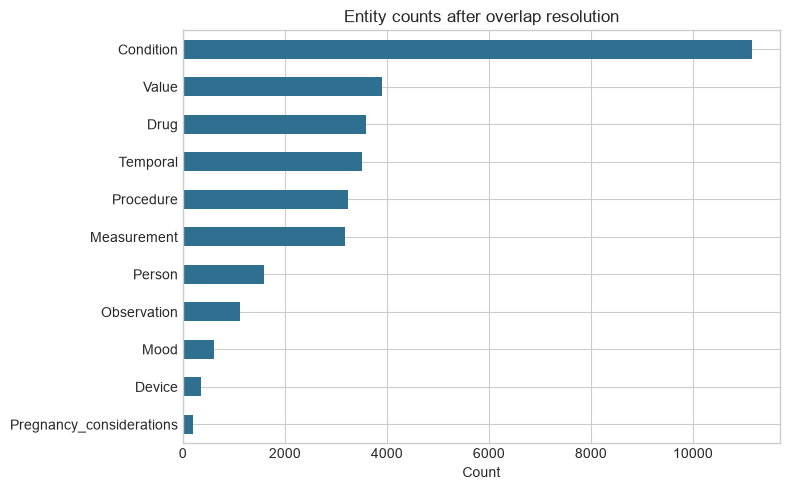

In [3]:
entity_counts = pd.Series(prep_audit["entity_type_counts"]).sort_values(ascending=True)
ax = entity_counts.plot(kind="barh", figsize=(8, 5), color="#2F6F8F")
ax.set_title("Entity counts after overlap resolution")
ax.set_xlabel("Count")
plt.tight_layout()
plt.show()

## 4. Pipeline demo: BIO alignment and CRF features

The example below shows criterion-level regex tokenization for the CRF baseline and
deterministic BIO alignment from character spans.

In [4]:
demo = CriterionExample(
    criterion_id="DEMO_inc:1",
    document_id="DEMO_inc",
    nct_id="DEMO",
    criteria_type="inclusion",
    line_number=1,
    text="Patients with diabetes and HbA1c above 7% receiving metformin.",
    entities=(
        ChiaEntity("T1", "Condition", ((14, 22),), "diabetes"),
        ChiaEntity("T2", "Measurement", ((27, 32),), "HbA1c"),
        ChiaEntity("T3", "Value", ((39, 41),), "7%"),
        ChiaEntity("T4", "Drug", ((52, 61),), "metformin"),
    ),
)

sequence = criterion_to_sequence(demo)
demo_table = pd.DataFrame(
    {
        "token": sequence.tokens,
        "start": [span[0] for span in sequence.offsets],
        "end": [span[1] for span in sequence.offsets],
        "bio_label": sequence.labels,
    }
)
demo_table

,token,start,end,bio_label
0,Patients,0,8,O
1,with,9,13,O
2,diabetes,14,22,B-Condition
3,and,23,26,O
4,HbA1c,27,32,B-Measurement
5,above,33,38,O
6,7,39,40,B-Value
7,%,40,41,I-Value
8,receiving,42,51,O
9,metformin,52,61,B-Drug


In [5]:
feature_preview = pd.Series(token_features(sequence.tokens, 3))
feature_preview

bias                 1.0000
word.lower              and
word.prefix2             an
word.prefix3            and
word.suffix2             nd
word.suffix3            and
word.shape                x
word.length               3
word.isupper          False
word.istitle          False
word.isdigit          False
word.hasdigit         False
-1:word.lower      diabetes
-1:word.shape             x
-1:word.istitle       False
-1:word.isupper       False
+1:word.lower         hba1c
+1:word.shape         XxXdx
+1:word.istitle       False
+1:word.isupper       False
dtype: object

## 4.1 Live DistilBERT prediction demo

The cell below loads the best validation-selected DistilBERT checkpoint and runs a
short prediction on the same demo criterion. Heavy training is not repeated. If the
checkpoint is missing locally, the cell reports that and continues with locked
artifact metrics.

In [6]:
import torch
from transformers import AutoModelForTokenClassification, AutoTokenizer

from trial_criteria_ner.transformer_data import ID_TO_LABEL, IGNORE_LABEL_ID

checkpoint_dir = ROOT / "checkpoints" / "distilbert" / "best"
if not checkpoint_dir.exists():
    print("DistilBERT checkpoint not found locally:", checkpoint_dir)
    print("Skipping live prediction; locked metrics below are still valid.")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir, use_fast=True)
    model = AutoModelForTokenClassification.from_pretrained(checkpoint_dir).to(device)
    model.eval()

    encoding = tokenizer(
        demo.text,
        return_offsets_mapping=True,
        return_tensors="pt",
        truncation=True,
        max_length=128,
    )
    offsets = encoding.pop("offset_mapping")[0].tolist()
    with torch.no_grad():
        logits = model(**{key: value.to(device) for key, value in encoding.items()}).logits
    predicted_ids = logits.argmax(dim=-1)[0].cpu().tolist()

    rows = []
    for (start, end), label_id in zip(offsets, predicted_ids, strict=True):
        if start == end:
            continue
        rows.append(
            {
                "token_text": demo.text[start:end],
                "start": start,
                "end": end,
                "predicted_bio": ID_TO_LABEL[label_id],
            }
        )
    distilbert_demo = pd.DataFrame(rows)
    display(distilbert_demo)
    print("Device:", device)
    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

Loading weights:   1%|          | 1/102 [00:00<00:11,  9.06it/s]

Loading weights:  18%|█▊        | 18/102 [00:00<00:00, 91.84it/s]

Loading weights:  34%|███▍      | 35/102 [00:00<00:00, 121.89it/s]

Loading weights:  52%|█████▏    | 53/102 [00:00<00:00, 134.22it/s]

Loading weights: 100%|██████████| 102/102 [00:00<00:00, 192.20it/s]

,token_text,start,end,predicted_bio
0,Patients,0,8,O
1,with,9,13,O
2,diabetes,14,22,B-Condition
3,and,23,26,O
4,H,27,28,B-Measurement
5,bA,28,30,I-Measurement
6,1,30,31,I-Measurement
7,c,31,32,I-Measurement
8,above,33,38,B-Value
9,7,39,40,I-Value


Device: cuda
GPU: NVIDIA GeForce GTX 1050 Ti


## 5. Models and training summary

| Model | Setup | Selection |
|---|---|---|
| CRF | regex tokens, lexical/context features, L-BFGS, `c1=c2=0.1`, 100 iterations | full train split |
| DistilBERT | WordPiece windows `max_length=128`, AdamW `2e-5`, accum 16, 5 epochs | best validation strict F1 |

The locked test set was unused until the final one-shot evaluation.

,epoch,train_mean_loss,validation_strict_f1,validation_relaxed_f1
0,1,1.2754,0.5924,0.7398
1,2,0.5759,0.6453,0.7783
2,3,0.4617,0.6542,0.7789
3,4,0.3927,0.6541,0.7827
4,5,0.3506,0.6594,0.7828


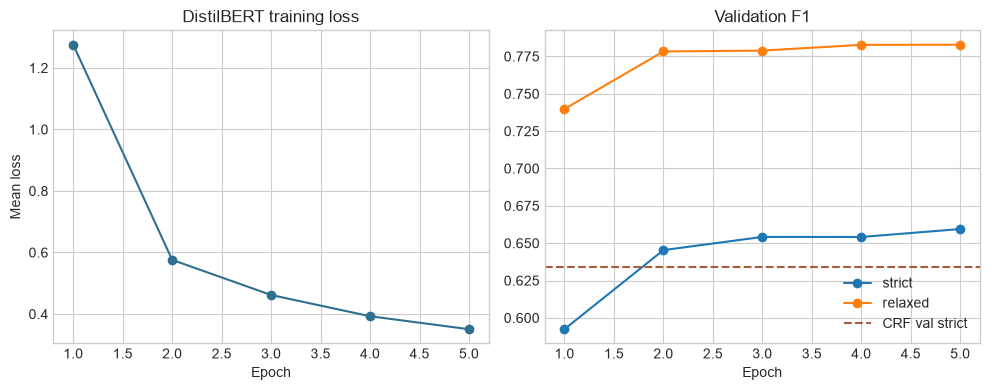

Best DistilBERT validation strict F1: 0.6594


In [7]:
training = json.loads((ARTIFACTS / "distilbert_training_metrics.json").read_text(encoding="utf-8"))
history = pd.DataFrame(training["epoch_history"])[
    ["epoch", "train_mean_loss", "validation_strict_f1", "validation_relaxed_f1"]
]
display(history)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history["epoch"], history["train_mean_loss"], marker="o", color="#2F6F8F")
axes[0].set_title("DistilBERT training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean loss")

axes[1].plot(history["epoch"], history["validation_strict_f1"], marker="o", label="strict")
axes[1].plot(history["epoch"], history["validation_relaxed_f1"], marker="o", label="relaxed")
axes[1].axhline(
    training["comparison_to_crf_validation"]["crf_strict_f1"],
    color="#A65D3F",
    linestyle="--",
    label="CRF val strict",
)
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

print(
    "Best DistilBERT validation strict F1:",
    round(training["best_checkpoint"]["validation_strict_f1"], 4),
)

The validation curves above show DistilBERT surpassing the CRF validation strict baseline
from epoch 2 onward. The best checkpoint is selected by validation F1 before any test use.

## 6. Locked test results: CRF vs DistilBERT

Primary metric: entity-level **strict micro-F1**. Relaxed overlap F1 and per-type
scores are secondary.

,model,strict_f1,relaxed_f1
0,CRF,0.5884,0.7275
1,DistilBERT,0.6192,0.7583


Winner (strict F1): distilbert
Strict delta (DistilBERT - CRF): 0.0308


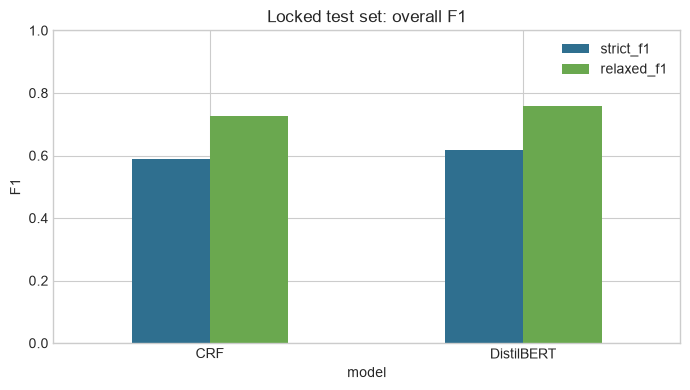

In [8]:
test_eval = json.loads((ARTIFACTS / "test_evaluation.json").read_text(encoding="utf-8"))
comparison = test_eval["comparison"]

overview = pd.DataFrame(
    [
        {
            "model": "CRF",
            "strict_f1": comparison["strict_f1_crf"],
            "relaxed_f1": comparison["relaxed_f1_crf"],
        },
        {
            "model": "DistilBERT",
            "strict_f1": comparison["strict_f1_distilbert"],
            "relaxed_f1": comparison["relaxed_f1_distilbert"],
        },
    ]
)
display(overview)
print("Winner (strict F1):", comparison["winner_strict"])
print("Strict delta (DistilBERT - CRF):", round(comparison["strict_f1_delta"], 4))

ax = overview.set_index("model")[["strict_f1", "relaxed_f1"]].plot(
    kind="bar",
    figsize=(7, 4),
    rot=0,
    color=["#2F6F8F", "#6AA84F"],
)
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
ax.set_title("Locked test set: overall F1")
plt.tight_layout()
plt.show()

,CRF,DistilBERT
inclusion,0.5410,0.5503
exclusion,0.6167,0.6628


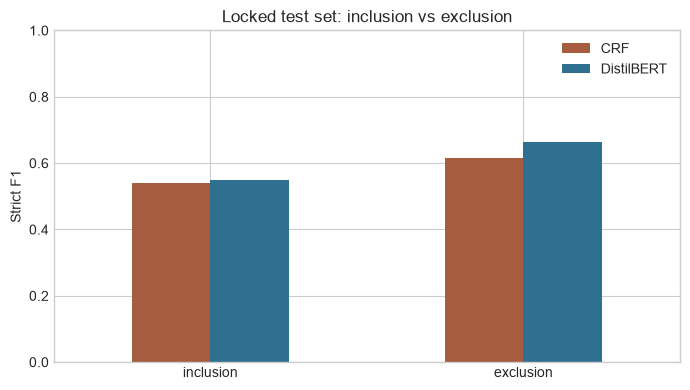

In [9]:
criteria_f1 = pd.DataFrame(
    {
        "CRF": [
            test_eval["crf"]["metrics"]["by_criteria_type"]["inclusion"]["strict"]["f1"],
            test_eval["crf"]["metrics"]["by_criteria_type"]["exclusion"]["strict"]["f1"],
        ],
        "DistilBERT": [
            test_eval["distilbert"]["metrics"]["by_criteria_type"]["inclusion"]["strict"]["f1"],
            test_eval["distilbert"]["metrics"]["by_criteria_type"]["exclusion"]["strict"]["f1"],
        ],
    },
    index=["inclusion", "exclusion"],
)
display(criteria_f1)
ax = criteria_f1.plot(kind="bar", figsize=(7, 4), rot=0, color=["#A65D3F", "#2F6F8F"])
ax.set_ylim(0, 1)
ax.set_ylabel("Strict F1")
ax.set_title("Locked test set: inclusion vs exclusion")
plt.tight_layout()
plt.show()

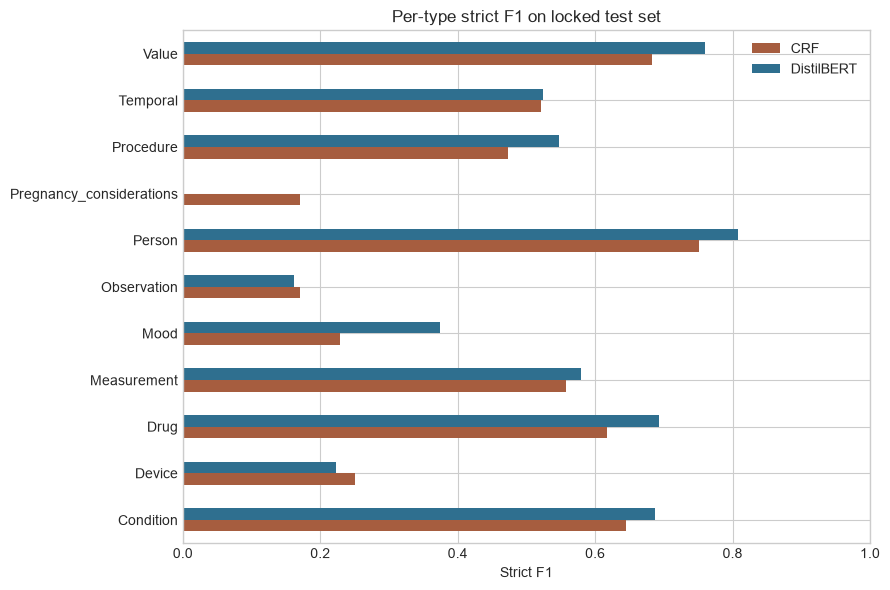

,CRF,DistilBERT
Condition,0.6446,0.6868
Device,0.2500,0.2222
Drug,0.6178,0.6922
Measurement,0.5582,0.5787
Mood,0.2292,0.3740
Observation,0.1705,0.1622
Person,0.7514,0.8076
Pregnancy_considerations,0.1702,0.0000
Procedure,0.4725,0.5476
Temporal,0.5216,0.5238


In [10]:
entity_types = sorted(test_eval["crf"]["metrics"]["per_type"])
per_type = pd.DataFrame(
    {
        "CRF": [
            test_eval["crf"]["metrics"]["per_type"][name]["strict"]["f1"]
            for name in entity_types
        ],
        "DistilBERT": [
            test_eval["distilbert"]["metrics"]["per_type"][name]["strict"]["f1"]
            for name in entity_types
        ],
    },
    index=entity_types,
)
ax = per_type.plot(kind="barh", figsize=(9, 6), color=["#A65D3F", "#2F6F8F"])
ax.set_xlim(0, 1)
ax.set_xlabel("Strict F1")
ax.set_title("Per-type strict F1 on locked test set")
plt.tight_layout()
plt.show()
per_type

,CRF,DistilBERT
boundary_error,478,541
exact_match,2021,2409
missed_entity,1068,610
spurious_entity,570,1019
type_error,117,126


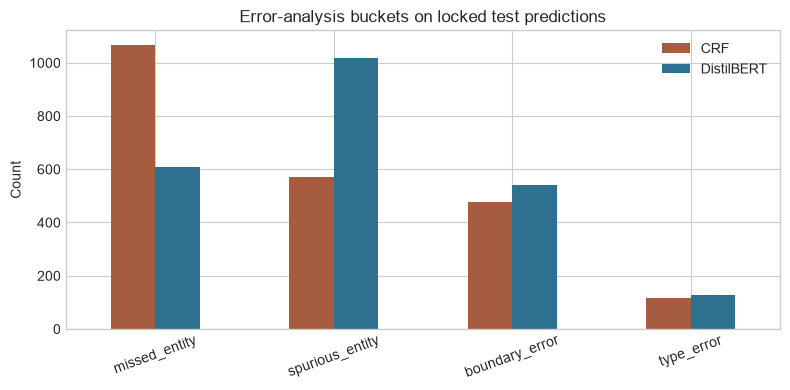

Example DistilBERT errors:
- NCT00404495_exc:2#w0 ['missed_entity']
  Concurrent administration of any other anti-tumor therapy
- NCT00404495_exc:3#w0 ['boundary_error', 'spurious_entity']
  Pre-existing uncontrolled diarrhea
- NCT00404495_inc:1#w0 ['missed_entity', 'spurious_entity']
  Cohort 1: Recurrent or refractory medulloblastoma in which current standard treatment approaches have failed; biopsy is not required for recurrent disease.


In [11]:
error_df = pd.DataFrame(
    {
        "CRF": test_eval["crf"]["error_counts"],
        "DistilBERT": test_eval["distilbert"]["error_counts"],
    }
).fillna(0)
display(error_df)

plot_cols = [
    name
    for name in [
        "missed_entity",
        "spurious_entity",
        "boundary_error",
        "type_error",
    ]
    if name in error_df.index
]
ax = error_df.loc[plot_cols].plot(kind="bar", figsize=(8, 4), rot=20, color=["#A65D3F", "#2F6F8F"])
ax.set_title("Error-analysis buckets on locked test predictions")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Example DistilBERT errors:")
for example in test_eval["distilbert"]["error_examples"][:3]:
    print("-", example["example_id"], example["error_kinds"])
    print(" ", example["text"][:160])

## 7. Comparison with previous research

| System | Notes | Strict F1 |
|---|---|---:|
| Zhang et al. BERT | published CHIA protocol | 0.6339 |
| Zhang et al. best RoBERTa-MIMIC-Trial | published CHIA protocol | 0.6578 |
| Our CRF | locked test, our preprocessing | 0.5884 |
| Our DistilBERT | locked test, 4 GB GPU budget | **0.6192** |

DistilBERT is smaller than the published BERT/RoBERTa setups and was trained under a
4 GB VRAM constraint. It does not surpass the best published transformer number, but
it **does** outperform our CRF baseline on the same held-out test set, which answers
the project research question.

## 8. Testing and reproducibility

Quality gates used throughout the project:

1. Environment / CUDA check
2. CHIA schema audit
3. BIO alignment unit tests
4. NCT leakage checks
5. CRF smoke + full baseline
6. DistilBERT smoke + checkpoint resume
7. Full DistilBERT training with validation selection
8. One-shot locked test evaluation

Run locally:

```powershell
$env:PYTHONPATH="src"
$env:PYTHONUTF8="1"
python -m pytest
python scripts\evaluate_test.py
```

Model weights stay in Git-ignored `checkpoints/` because of GitHub size limits.

In [12]:
# Lightweight integrity check used by the notebook itself.
assert test_eval["training_performed"] is False
assert test_eval["test_split"]["nct_id_count"] == 100
assert test_eval["test_split"]["criterion_count"] == 1310
assert comparison["strict_f1_distilbert"] > comparison["strict_f1_crf"]
assert prep_audit["nct_leakage_count"] == 0
print("Notebook integrity checks passed.")

Notebook integrity checks passed.


## 9. Conclusion

On the locked CHIA test split, DistilBERT reaches strict F1 **0.6192** versus CRF
**0.5884** (`+0.0308`). Relaxed F1 improves by a similar margin. DistilBERT misses
fewer entities but produces more spurious spans, and boundary errors remain common.

**Answer to the research question:** yes — under the same held-out protocol, the
compact transformer outperforms the classical CRF baseline for eligibility-criteria NER.

Limitations: DistilBERT still trails larger published transformers; preprocessing is
not an exact paper replica; and the system extracts entities only — it does not assess
patient eligibility.

## References

- Kury et al., [Chia, a large annotated corpus of clinical trial eligibility criteria](https://doi.org/10.1038/s41597-020-00620-0).
- Zhang et al., [Transformer-Based Named Entity Recognition for Parsing Clinical Trial Eligibility Criteria](https://pmc.ncbi.nlm.nih.gov/articles/PMC8373041/).
- Detailed design notes: `docs/PROJECT_DESIGN.md`.